In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================
from google.colab import files
uploaded=files.upload()


Saving combined_output.csv to combined_output.csv


Dataset Shape: (9667, 8)

Missing Values:
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64


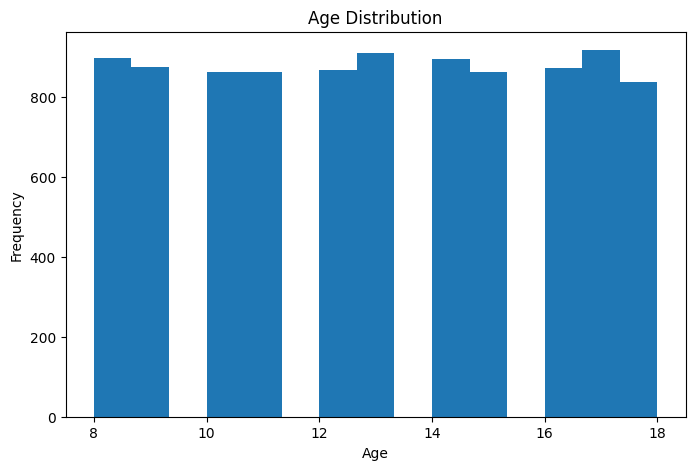

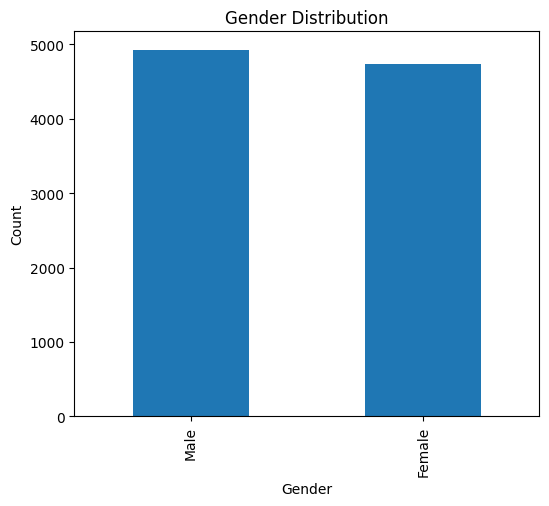

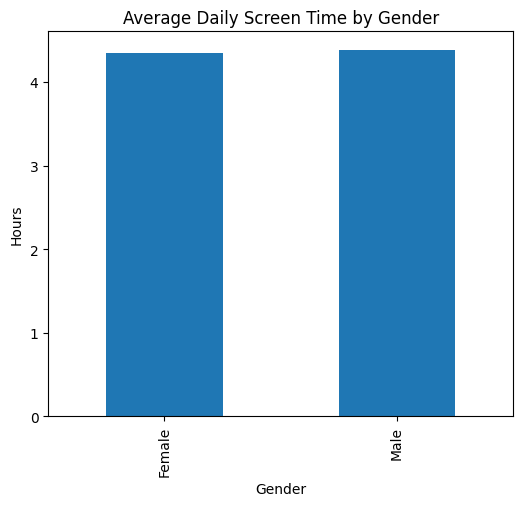

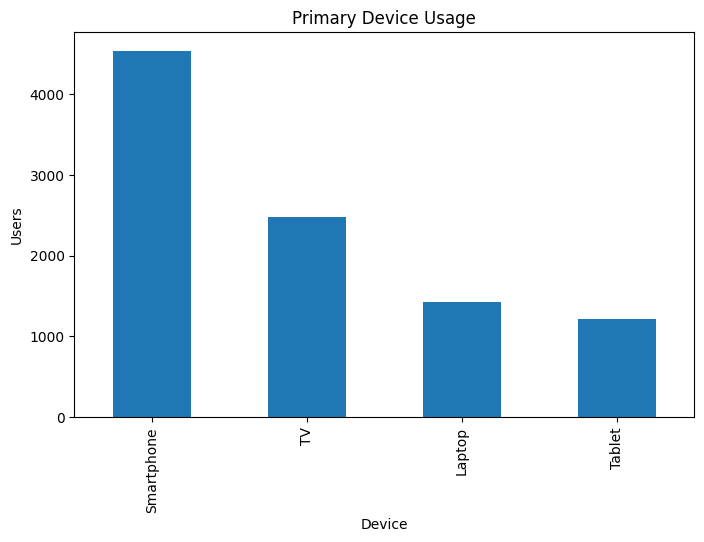

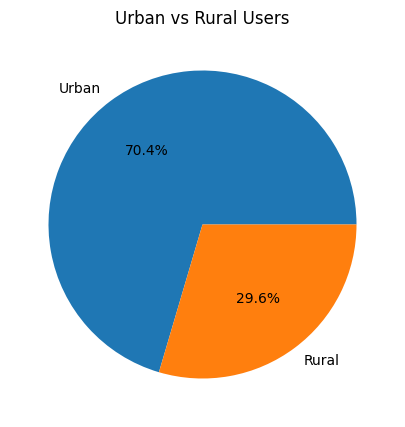

In [ ]:
df = pd.read_csv("combined_output.csv")

# ==========================
# Data Cleaning
# ==========================

# Remove duplicates
df = df.drop_duplicates()

# Remove completely empty rows
df = df.dropna(how='all')

# Fill missing values
for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# ==========================
# Visualization 1
# Age Distribution
# ==========================

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ==========================
# Visualization 2
# Gender Distribution
# ==========================

plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ==========================
# Visualization 3
# Average Screen Time by Gender
# ==========================

avg_screen_time = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
avg_screen_time.plot(kind='bar')
plt.title("Average Daily Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Hours")
plt.show()

# ==========================
# Visualization 4
# Device Usage
# ==========================

plt.figure(figsize=(8,5))
df['Primary_Device'].value_counts().plot(kind='bar')
plt.title("Primary Device Usage")
plt.xlabel("Device")
plt.ylabel("Users")
plt.show()

# ==========================
# Visualization 5
# Urban vs Rural
# ==========================

plt.figure(figsize=(6,5))
df['Urban_or_Rural'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Urban vs Rural Users")
plt.ylabel("")
plt.show()

